In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path
from PIL import Image
from defect_detection.utils import find_project_root, load_yaml_config

sns.set_theme(style="whitegrid")

PROJECT_ROOT = find_project_root()
config = load_yaml_config("config/data_config.yaml")

MVTEC_DIR = PROJECT_ROOT / config["paths"]["mvtec_dir"]
CATEGORIES = config["mvtec"]["categories"]

#### Basic inventory: image counts per category and per defect type

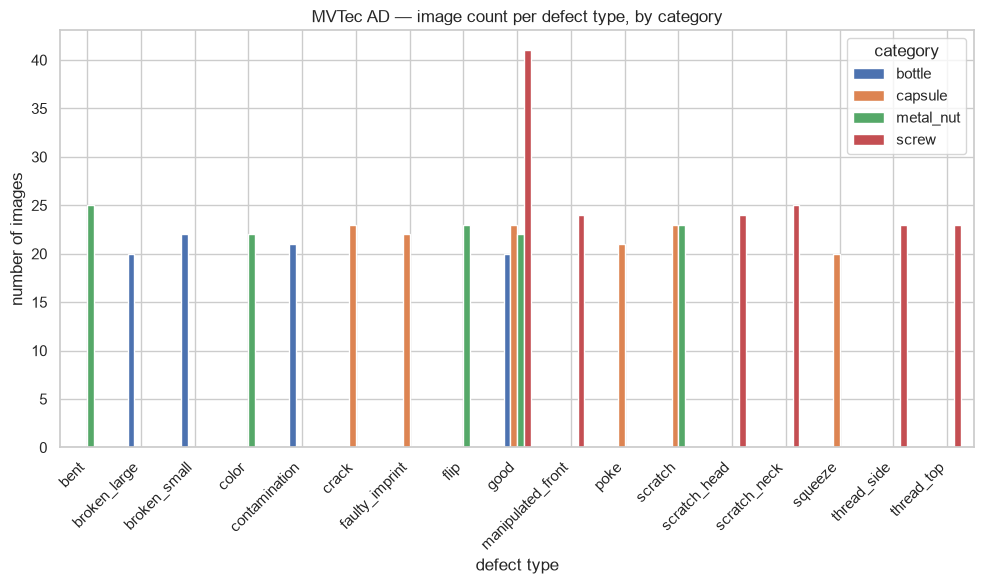

In [ ]:

inventory_records = []
for category in CATEGORIES:
    test_dir = MVTEC_DIR / category / "test"
    for defect_type_dir in sorted(test_dir.iterdir()):
        if defect_type_dir.is_dir():
            n_images = len(list(defect_type_dir.glob("*.png")))
            inventory_records.append({
                "category": category,
                "defect_type": defect_type_dir.name,
                "n_images": n_images,
            })
 
inventory_df = pd.DataFrame(inventory_records)
inventory_pivot = inventory_df.pivot(index="defect_type", columns="category", values="n_images").fillna(0).astype(int)
 
fig, ax = plt.subplots(figsize=(10, 6))
inventory_pivot.plot(kind="bar", ax=ax)
ax.set_title("MVTec AD — image count per defect type, by category")
ax.set_xlabel("defect type")
ax.set_ylabel("number of images")
ax.legend(title="category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Defect area ratio distribution per category

           count      mean       std       min       25%       50%       75%  \
category                                                                       
bottle      63.0  0.076166  0.057601  0.005757  0.025741  0.057178  0.128291   
capsule    109.0  0.011089  0.018403  0.000371  0.002479  0.004295  0.008496   
metal_nut   93.0  0.144888  0.195727  0.004357  0.018982  0.036714  0.123010   
screw      119.0  0.003355  0.001666  0.000985  0.002321  0.002879  0.003984   

                max  
category             
bottle     0.274186  
capsule    0.080787  
metal_nut  0.487247  
screw      0.010108  


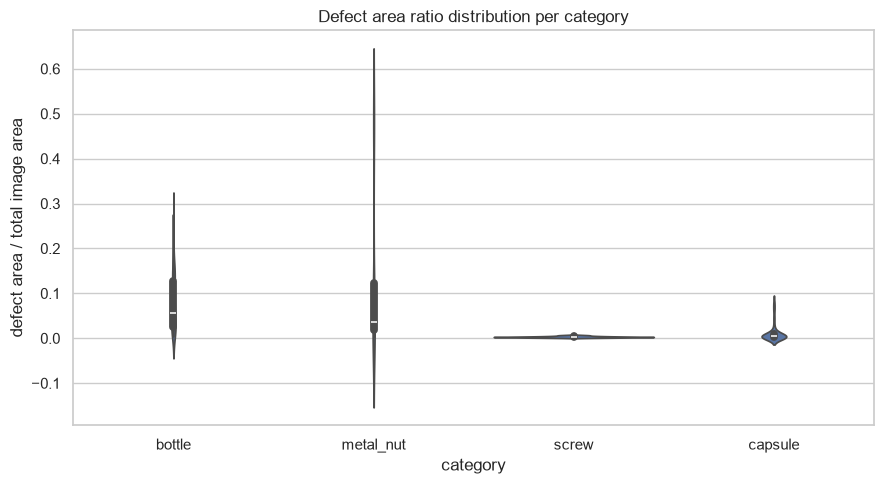

In [ ]:

def get_defect_area_ratio(mask_path: Path) -> float:
    mask = np.array(Image.open(mask_path).convert("L"))
    return float(np.sum(mask > 127) / mask.size)
 
 
area_records = []
for category in CATEGORIES:
    gt_dir = MVTEC_DIR / category / "ground_truth"
    if not gt_dir.exists():
        continue
    for defect_type_dir in sorted(gt_dir.iterdir()):
        if not defect_type_dir.is_dir():
            continue
        for mask_path in defect_type_dir.glob("*.png"):
            ratio = get_defect_area_ratio(mask_path)
            area_records.append({
                "category": category,
                "defect_type": defect_type_dir.name,
                "area_ratio": ratio,
            })
 
area_df = pd.DataFrame(area_records)
print(area_df.groupby("category")["area_ratio"].describe())
 
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=area_df, x="category", y="area_ratio", ax=ax, order=CATEGORIES)
ax.set_title("Defect area ratio distribution per category")
ax.set_xlabel("category")
ax.set_ylabel("defect area / total image area")
plt.tight_layout()
plt.show()

#### Visual inspection: sample images and masks side by side, per category and defect type

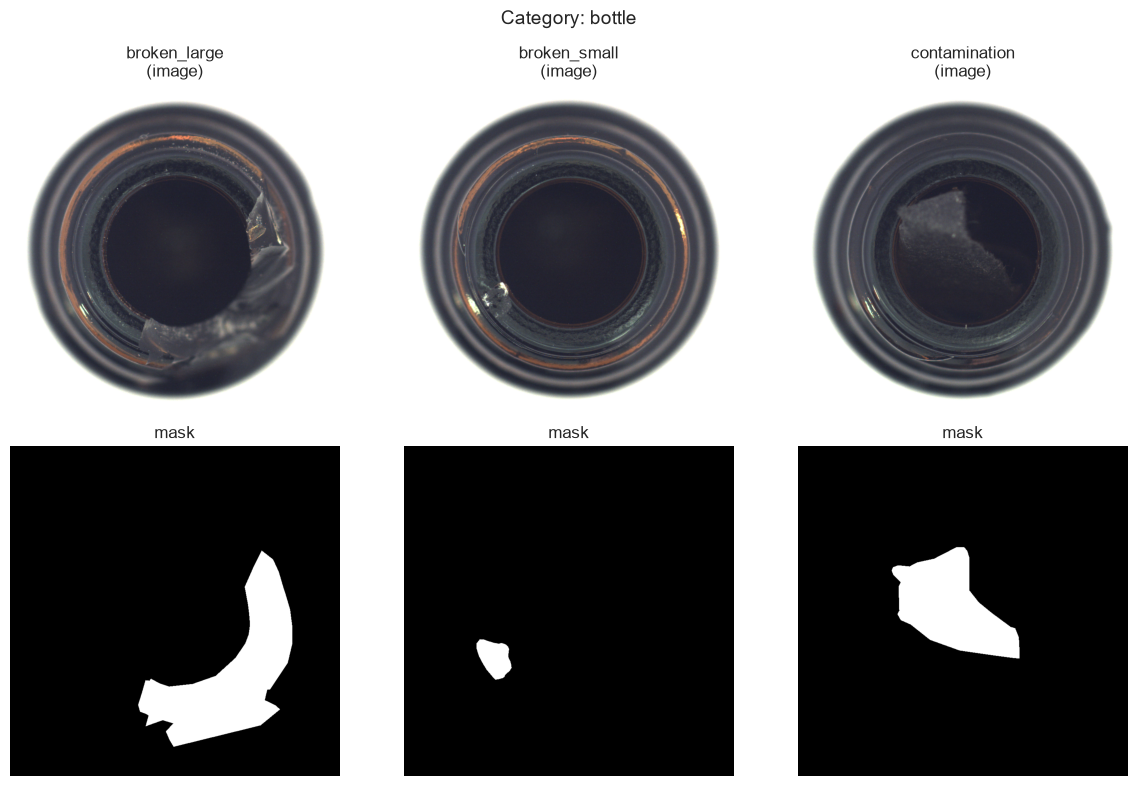

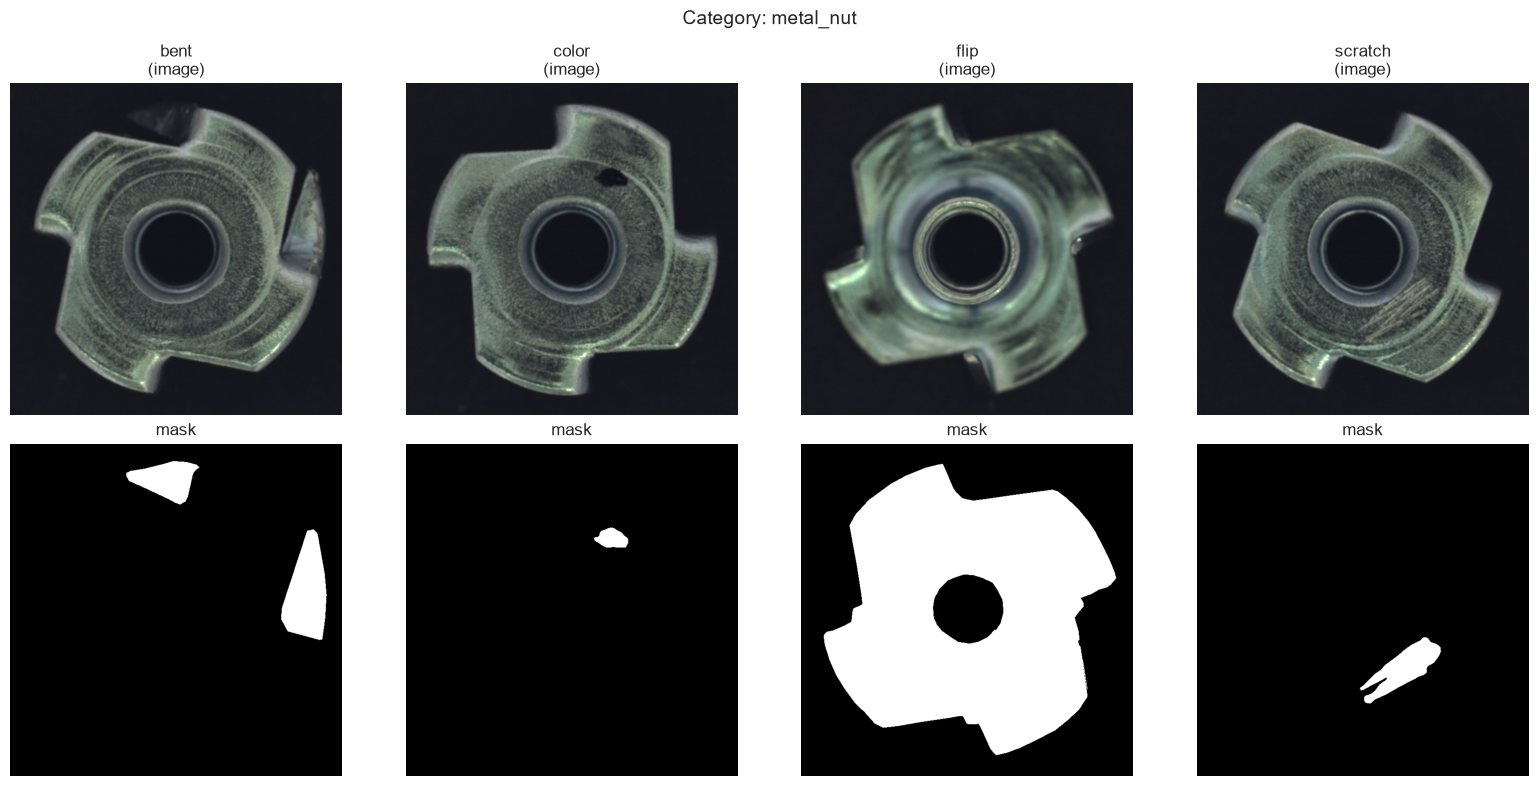

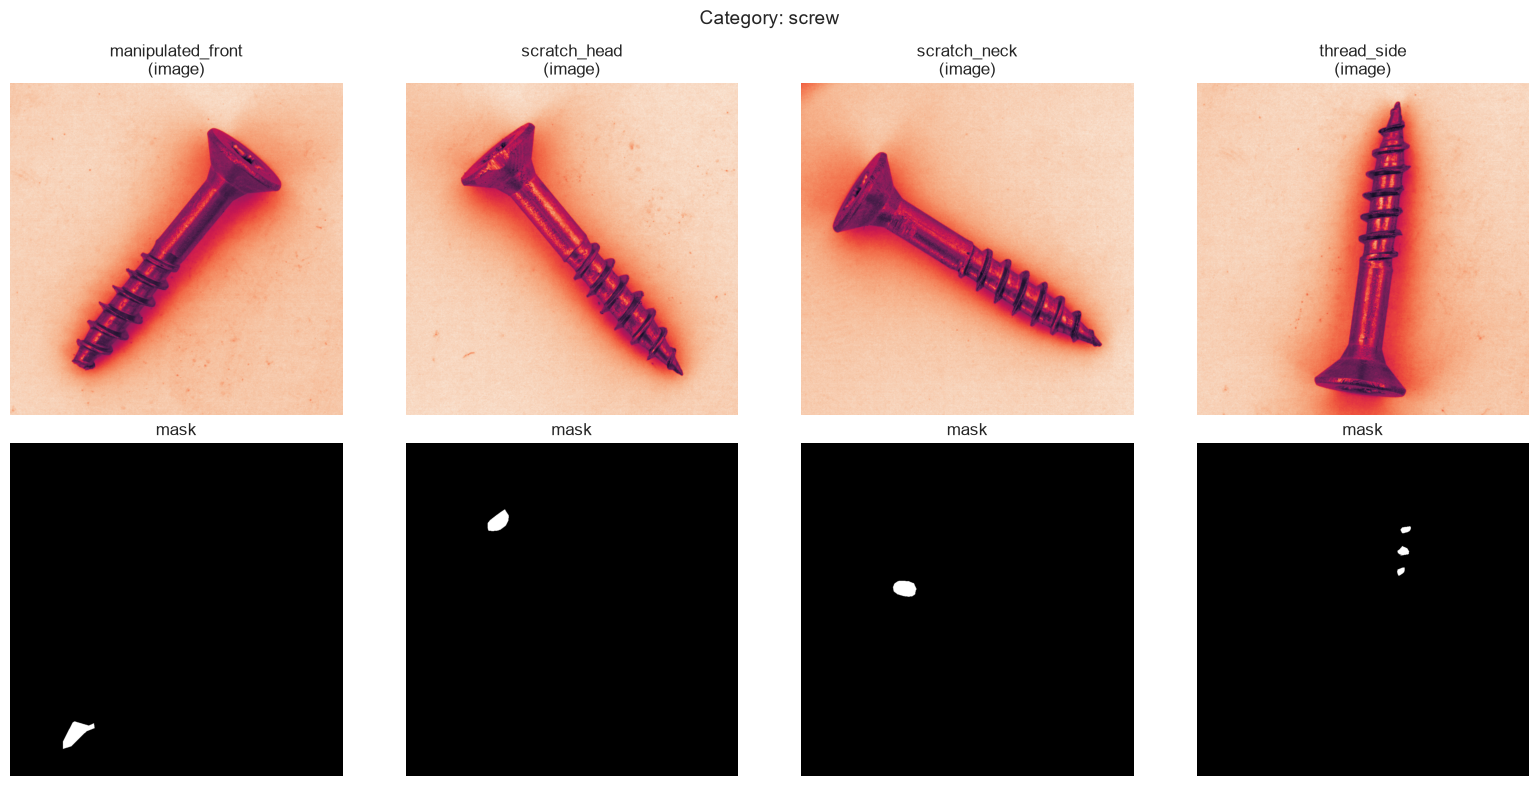

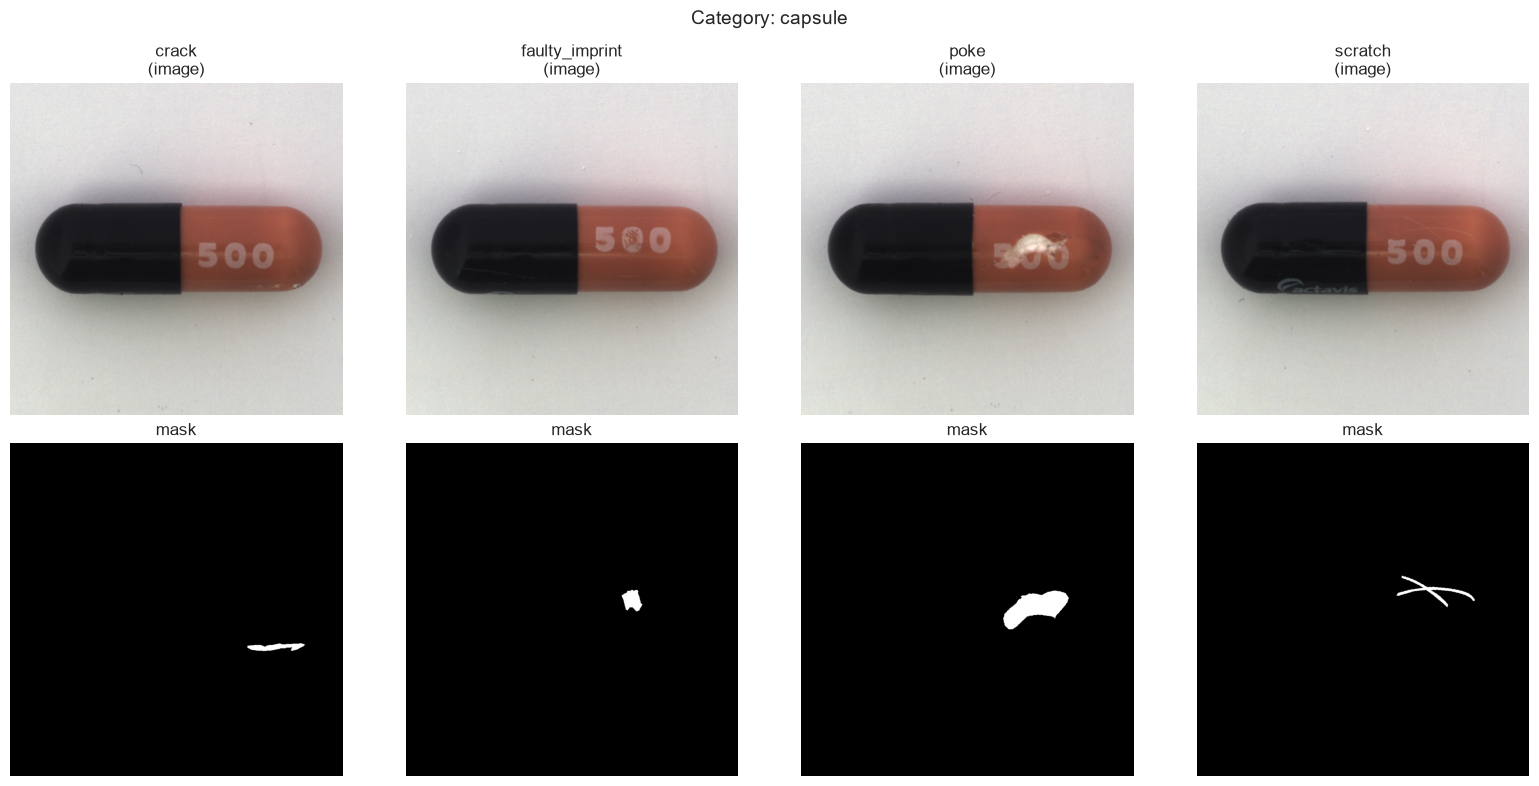

In [ ]:

def show_category_samples(category: str, n_defect_types: int = 4):
    gt_dir = MVTEC_DIR / category / "ground_truth"
    test_dir = MVTEC_DIR / category / "test"
 
    defect_dirs = sorted([d for d in gt_dir.iterdir() if d.is_dir()])[:n_defect_types]
 
    fig, axes = plt.subplots(2, len(defect_dirs), figsize=(4 * len(defect_dirs), 8))
    if len(defect_dirs) == 1:
        axes = axes.reshape(2, 1)
 
    for i, defect_dir in enumerate(defect_dirs):
        mask_paths = sorted(defect_dir.glob("*.png"))
        if not mask_paths:
            continue
        mask_path = mask_paths[0]
        image_id = mask_path.stem.replace("_mask", "")
        image_path = test_dir / defect_dir.name / f"{image_id}.png"
 
        if not image_path.exists():
            continue
 
        axes[0, i].imshow(Image.open(image_path))
        axes[0, i].set_title(f"{defect_dir.name}\n(image)")
        axes[0, i].axis("off")
 
        axes[1, i].imshow(Image.open(mask_path), cmap="gray")
        axes[1, i].set_title("mask")
        axes[1, i].axis("off")
 
    fig.suptitle(f"Category: {category}", fontsize=14)
    plt.tight_layout()
    plt.show()
 
for category in CATEGORIES:
    show_category_samples(category)

#### Defect type distribution per category

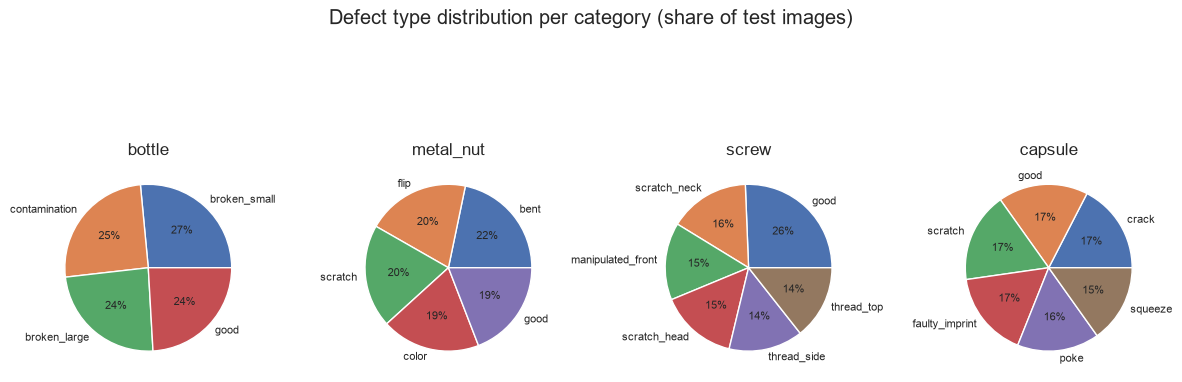

In [ ]:

category_totals = inventory_df.groupby("category")["n_images"].transform("sum")
inventory_df["proportion"] = inventory_df["n_images"] / category_totals
 
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(3 * len(CATEGORIES), 5))
 
for ax, category in zip(axes, CATEGORIES):
    subset = inventory_df[inventory_df.category == category].sort_values("n_images", ascending=False)
    ax.pie(subset["n_images"], labels=subset["defect_type"], autopct="%1.0f%%", textprops={"fontsize": 8})
    ax.set_title(category)
 
plt.suptitle("Defect type distribution per category (share of test images)")
plt.tight_layout()
plt.show()

#### Good (defect-free) vs defective image counts per category

    category  good_train  good_test  good_total  defect_total
0     bottle         209         20         229            63
1  metal_nut         220         22         242            93
2      screw         320         41         361           119
3    capsule         219         23         242           109


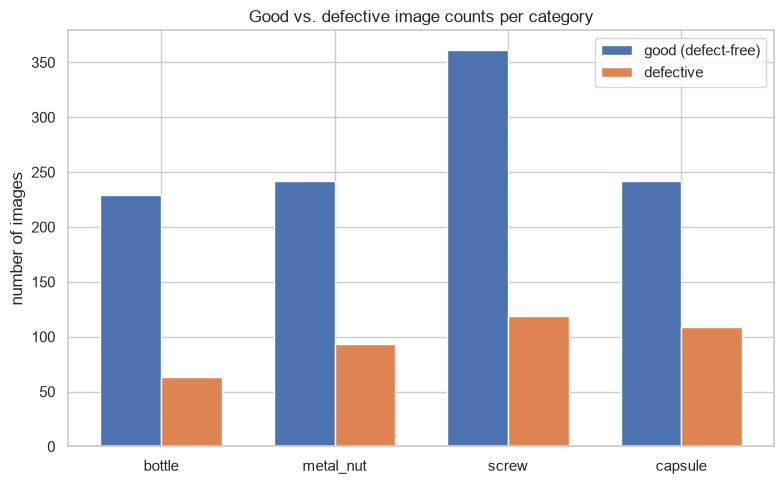

In [ ]:

good_records = []
for category in CATEGORIES:
    n_good_train = len(list((MVTEC_DIR / category / "train" / "good").glob("*.png")))
    n_good_test = len(list((MVTEC_DIR / category / "test" / "good").glob("*.png")))
    n_defect_total = int(inventory_df.loc[
        (inventory_df.category == category) & (inventory_df.defect_type != "good"), "n_images"
    ].sum())
 
    good_records.append({
        "category": category,
        "good_train": n_good_train,
        "good_test": n_good_test,
        "good_total": n_good_train + n_good_test,
        "defect_total": n_defect_total,
    })
 
good_df = pd.DataFrame(good_records)
print(good_df)
 
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(CATEGORIES))
width = 0.35
 
ax.bar(x - width / 2, good_df["good_total"], width, label="good (defect-free)")
ax.bar(x + width / 2, good_df["defect_total"], width, label="defective")
 
ax.set_xticks(x)
ax.set_xticklabels(good_df["category"])
ax.set_ylabel("number of images")
ax.set_title("Good vs. defective image counts per category")
ax.legend()
plt.tight_layout()
plt.show()

## Summary for MVTec EDA

### Inventory and class balance

- **Within-category defect-subtype counts are reasonably balanced** (mostly 20–25 images per
  subtype across all 4 categories). No single defect subtype is severely underrepresented
  relative to others in the same category.
- **Good vs. defective is meaningfully imbalanced** across all 4 categories, roughly
  2.2:1 to 3.6:1 in favor of good images (bottle 228:63, metal_nut 242:93, screw 361:118,
  capsule 242:108). This directly affects the binary defect-gate head.
- **Fault-type balance (after applying the defect-to-fault-type mapping)** is milder but still
  present: outer_race (~113 images) is the largest mapped class, ball (~65 images) the
  smallest, roughly a 1.7:1 ratio.

### Defect-to-fault-type mapping visual sanity check

- **Strong fits, confirmed visually**: `metal_nut` `bent` (clear structural deformation) →
  inner_race, `metal_nut`/`screw` `scratch*` (thin, localized surface marks) → outer_race,
  `bottle` `broken_large`/`broken_small` (substantial chunk-shaped damage) → inner_race,
  `bottle` `contamination` (surface deposit) → outer_race.
- **Weaker fits, worth flagging as a known limitation**: `capsule` `crack` and `capsule`
  `scratch` present very similarly in mask geometry (both thin curved/linear marks), so the
  inner_race/outer_race distinction for capsule relies more on semantic labeling than on
  visually distinguishable damage patterns. `screw` `manipulated_front` → ball is also a
  weaker visual fit. The mask doesn't clearly evoke irregular/compound damage the way the
  mechanical reasoning intended.
- **Excluded defect subtypes were correctly scoped out**: `metal_nut` `flip` (mask covers
  nearly the whole object, not a localized defect), `metal_nut` `color` and `capsule`
  `faulty_imprint` (diffuse/printing-related, not mechanical damage), `screw` `thread_side`/
  `thread_top` (multiple scattered small defects, ambiguous single-class assignment). The
  sample images confirm these were reasonable exclusions.

### Implications for the project

1. **Class imbalance handling (already planned) is necessary, not optional.** Focal loss and/or
   class weighting should be applied to both the binary defect-gate head (2–4:1 imbalance) and
   the 3-class fault-type head (~1.7:1 imbalance). Geometric/photometric augmentation for
   images remains the appropriate imbalance strategy at the image level. SMOTE remains reserved
   for the vibration feature vectors only, per the earlier design decision.
2. **Stratified splitting should account for both `is_defect` and `fault_class`**, consistent
   with the combined stratification key already planned for the manifest, given the imbalance
   confirmed here.
3. **The defect-to-fault-type mapping is reasonable overall and can be used as-is**, but the
   capsule crack/scratch distinction and screw manipulated_front→ball mapping should be
   explicitly acknowledged in the project write-up as weaker, more semantically-driven
   assignments rather than strongly visually self-evident ones. This is consistent with the
   project's overall stance that the fault-type mapping is a stated modeling assumption
   grounded in mechanical reasoning, not an empirically validated correspondence.